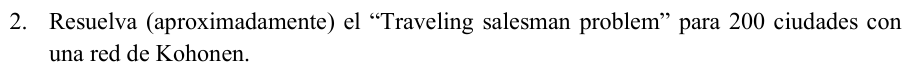

In [ ]:
import numpy as np

class KohonenTSP:
    def __init__(self, n_cities, n_neurons_factor=2.5, seed=None):
        self.n_cities = n_cities
        self.n_neurons = int(n_cities * n_neurons_factor)
        self.rng = np.random.default_rng(seed)
        # inicializa el anillo en un círculo unitario
        angles = np.linspace(0, 2 * np.pi, self.n_neurons, endpoint=False)
        self.weights = np.column_stack([np.cos(angles), np.sin(angles)])

    def _init_around_cities(self, cities, radius_factor=0.3):
        # centra el anillo en el centroide de las ciudades
        centroid = cities.mean(axis=0)
        spread = cities.std(axis=0).mean()
        radius = spread * radius_factor
        angles = np.linspace(0, 2 * np.pi, self.n_neurons, endpoint=False)
        circle = np.column_stack([np.cos(angles), np.sin(angles)])
        self.weights = centroid + radius * circle

    def _ring_distance(self, i, j):
        # distancia circular de índices (no euclídea)
        direct = np.abs(i - j)
        return np.minimum(direct, self.n_neurons - direct)

    def _neighborhood(self, winner_idx, sigma):
        # gaussiana centrada en la neurona ganadora, ancho = sigma
        idx = np.arange(self.n_neurons)
        d = self._ring_distance(idx, winner_idx)
        return np.exp(-(d ** 2) / (2 * sigma ** 2))

    def _find_winner(self, city):
        # BMU: neurona más cercana a la ciudad
        dists = np.linalg.norm(self.weights - city, axis=1)
        return np.argmin(dists)

    def _train_step(self, city, eta, sigma):
        # eta fijo, sigma variable
        winner = self._find_winner(city)
        h = self._neighborhood(winner, sigma)
        self.weights += eta * h[:, np.newaxis] * (city - self.weights)

    def train(self, cities, sigma_inicial, n_epochs, eta=0.3, sigma_final=0.5,
              verbose=True, n_snapshots=5):
        # una epoca = pasar por todas las ciudades (en orden aleatorio)
        self._init_around_cities(cities)
        n_iterations = n_epochs * self.n_cities

        # epocas en las que se guarda una copia de los pesos
        snapshot_epochs = set(np.linspace(0, n_epochs - 1, n_snapshots, dtype=int))
        self.snapshots = []

        t = 0
        for epoch in range(n_epochs):
            ciudades_orden = self.rng.permutation(cities)
            for city in ciudades_orden:
                frac = t / n_iterations
                sigma = sigma_inicial * (sigma_final / sigma_inicial) ** frac
                self._train_step(city, eta=eta, sigma=sigma)
                t += 1

            if epoch in snapshot_epochs:
                self.snapshots.append((epoch, self.weights.copy()))

            if verbose and epoch % max(1, n_epochs // 10) == 0:
                print(f"epoca {epoch}/{n_epochs}, sigma={sigma:.3f}")

epoca 0/100, sigma=94.865
epoca 10/100, sigma=55.847
epoca 20/100, sigma=32.877
epoca 30/100, sigma=19.355
epoca 40/100, sigma=11.394
epoca 50/100, sigma=6.708
epoca 60/100, sigma=3.949
epoca 70/100, sigma=2.325
epoca 80/100, sigma=1.369
epoca 90/100, sigma=0.806


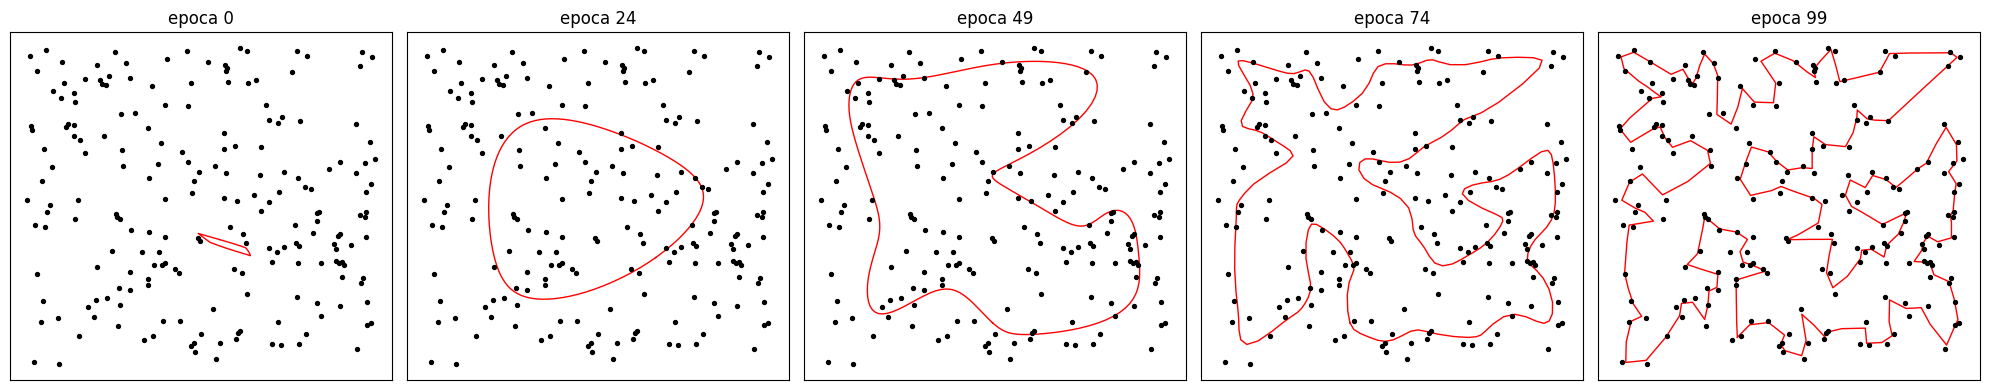

Longitud del camino: 959.1396379033852


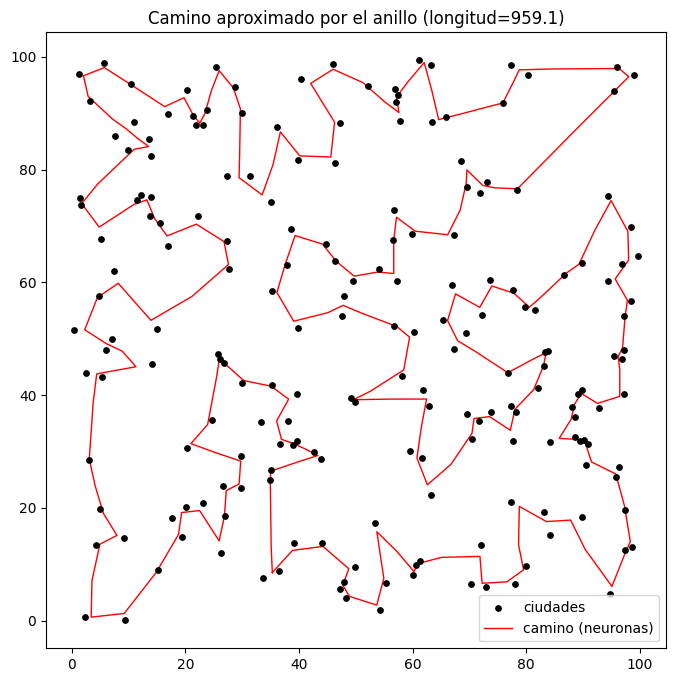

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def path_length(path):
    # suma distancias entre puntos consecutivos del camino, cerrando el ciclo
    diffs = np.diff(np.vstack([path, path[0]]), axis=0)
    return np.sum(np.linalg.norm(diffs, axis=1))

SEED = 110221

# generar ciudades random
n_cities = 200
rng = np.random.default_rng(SEED)
cities = rng.uniform(0, 100, size=(n_cities, 2))

# entrenar la red
som = KohonenTSP(n_cities=n_cities, n_neurons_factor=1, seed=SEED)
som.train(cities, sigma_inicial=som.n_neurons / 2, n_epochs=100, n_snapshots=5)

# progreso: 5 imagenes side by side
fig, axes = plt.subplots(1, len(som.snapshots), figsize=(4 * len(som.snapshots), 4))
for ax, (epoch, weights) in zip(axes, som.snapshots):
    closed = np.vstack([weights, weights[0]])
    ax.scatter(cities[:, 0], cities[:, 1], s=8, c='black', zorder=2)
    ax.plot(closed[:, 0], closed[:, 1], c='red', linewidth=1, zorder=1)
    ax.set_title(f"epoca {epoch}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# figura final, mas grande, debajo del progreso
path = som.weights
length = path_length(path)
print("Longitud del camino:", length)

closed_path = np.vstack([path, path[0]])
plt.figure(figsize=(8, 8))
plt.scatter(cities[:, 0], cities[:, 1], s=15, c='black', zorder=2, label='ciudades')
plt.plot(closed_path[:, 0], closed_path[:, 1], c='red', linewidth=1, zorder=1, label='camino (neuronas)')
plt.legend()
plt.title(f"Camino aproximado por el anillo (longitud={length:.1f})")
plt.show()

epoca 0/100, sigma=188.425
epoca 10/100, sigma=103.498
epoca 20/100, sigma=56.850
epoca 30/100, sigma=31.226
epoca 40/100, sigma=17.152
epoca 50/100, sigma=9.421
epoca 60/100, sigma=5.175
epoca 70/100, sigma=2.842
epoca 80/100, sigma=1.561
epoca 90/100, sigma=0.858


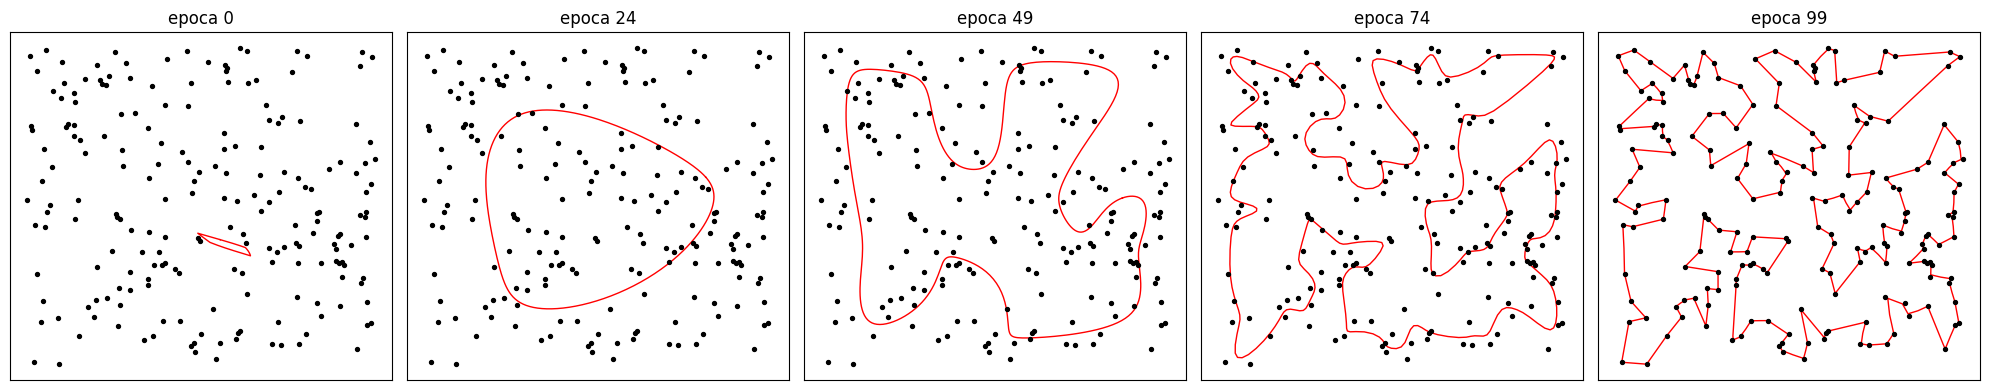

Longitud del camino: 1111.4978849379534


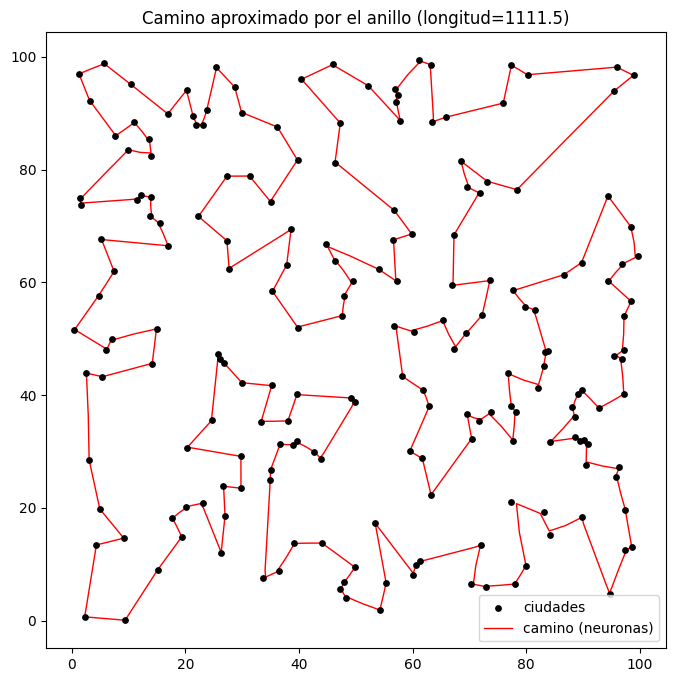

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def path_length(path):
    # suma distancias entre puntos consecutivos del camino, cerrando el ciclo
    diffs = np.diff(np.vstack([path, path[0]]), axis=0)
    return np.sum(np.linalg.norm(diffs, axis=1))

SEED = 110221

# generar ciudades random
n_cities = 200
rng = np.random.default_rng(SEED)
cities = rng.uniform(0, 100, size=(n_cities, 2))

# entrenar la red
som = KohonenTSP(n_cities=n_cities, n_neurons_factor=2, seed=SEED)
som.train(cities, sigma_inicial=som.n_neurons / 2, n_epochs=100, n_snapshots=5)

# progreso: 5 imagenes side by side
fig, axes = plt.subplots(1, len(som.snapshots), figsize=(4 * len(som.snapshots), 4))
for ax, (epoch, weights) in zip(axes, som.snapshots):
    closed = np.vstack([weights, weights[0]])
    ax.scatter(cities[:, 0], cities[:, 1], s=8, c='black', zorder=2)
    ax.plot(closed[:, 0], closed[:, 1], c='red', linewidth=1, zorder=1)
    ax.set_title(f"epoca {epoch}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# figura final, mas grande, debajo del progreso
path = som.weights
length = path_length(path)
print("Longitud del camino:", length)

closed_path = np.vstack([path, path[0]])
plt.figure(figsize=(8, 8))
plt.scatter(cities[:, 0], cities[:, 1], s=15, c='black', zorder=2, label='ciudades')
plt.plot(closed_path[:, 0], closed_path[:, 1], c='red', linewidth=1, zorder=1, label='camino (neuronas)')
plt.legend()
plt.title(f"Camino aproximado por el anillo (longitud={length:.1f})")
plt.show()

epoca 0/100, sigma=281.500
epoca 10/100, sigma=148.478
epoca 20/100, sigma=78.316
epoca 30/100, sigma=41.308
epoca 40/100, sigma=21.788
epoca 50/100, sigma=11.492
epoca 60/100, sigma=6.062
epoca 70/100, sigma=3.197
epoca 80/100, sigma=1.686
epoca 90/100, sigma=0.889


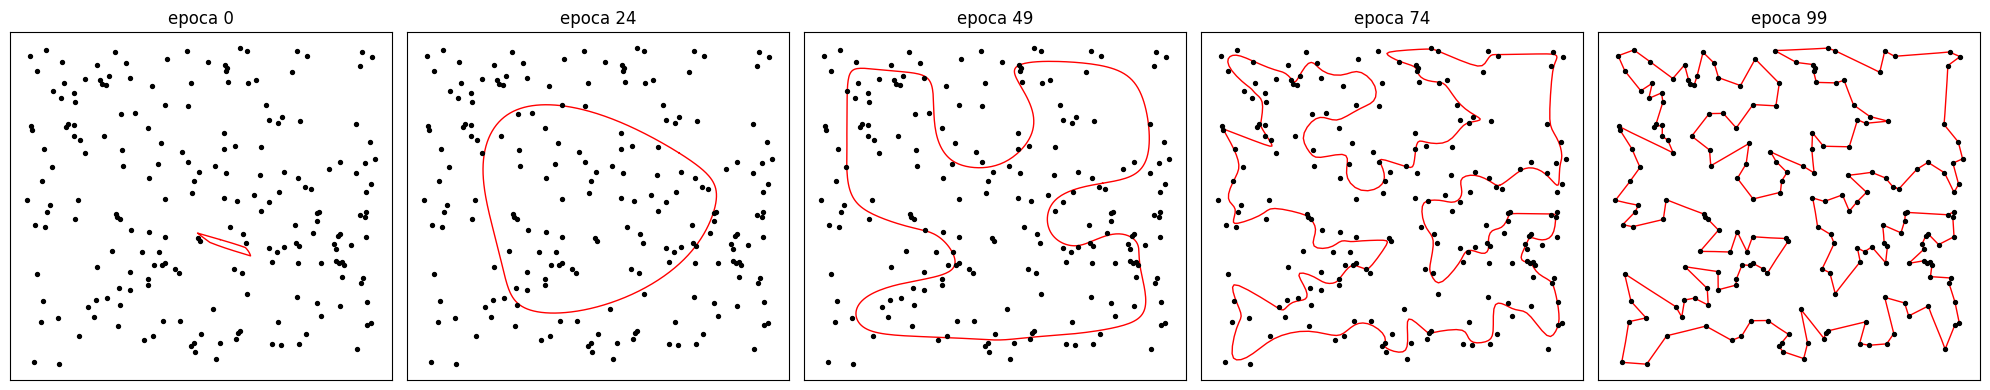

Longitud del camino: 1136.0596162659904


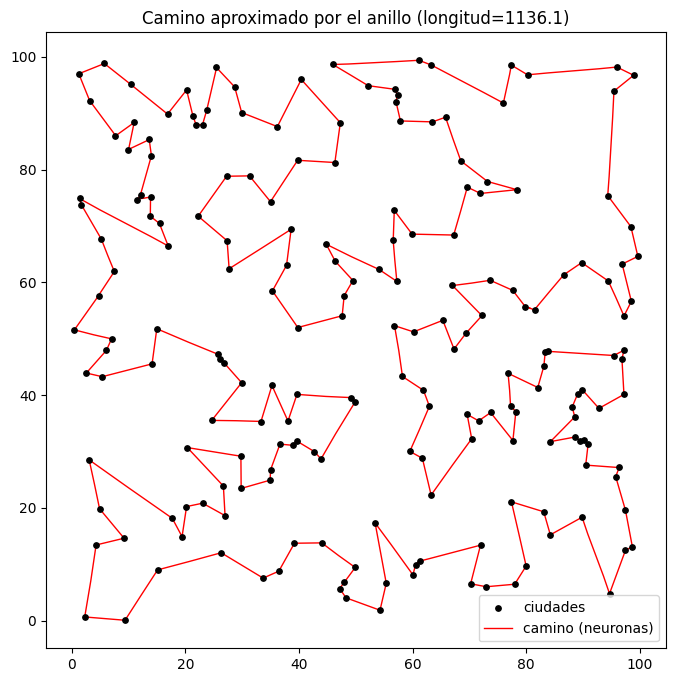

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def path_length(path):
    # suma distancias entre puntos consecutivos del camino, cerrando el ciclo
    diffs = np.diff(np.vstack([path, path[0]]), axis=0)
    return np.sum(np.linalg.norm(diffs, axis=1))

SEED = 110221

# generar ciudades random
n_cities = 200
rng = np.random.default_rng(SEED)
cities = rng.uniform(0, 100, size=(n_cities, 2))

# entrenar la red
som = KohonenTSP(n_cities=n_cities, n_neurons_factor=3, seed=SEED)
som.train(cities, sigma_inicial=som.n_neurons / 2, n_epochs=100, n_snapshots=5)

# progreso: 5 imagenes side by side
fig, axes = plt.subplots(1, len(som.snapshots), figsize=(4 * len(som.snapshots), 4))
for ax, (epoch, weights) in zip(axes, som.snapshots):
    closed = np.vstack([weights, weights[0]])
    ax.scatter(cities[:, 0], cities[:, 1], s=8, c='black', zorder=2)
    ax.plot(closed[:, 0], closed[:, 1], c='red', linewidth=1, zorder=1)
    ax.set_title(f"epoca {epoch}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# figura final, mas grande, debajo del progreso
path = som.weights
length = path_length(path)
print("Longitud del camino:", length)

closed_path = np.vstack([path, path[0]])
plt.figure(figsize=(8, 8))
plt.scatter(cities[:, 0], cities[:, 1], s=15, c='black', zorder=2, label='ciudades')
plt.plot(closed_path[:, 0], closed_path[:, 1], c='red', linewidth=1, zorder=1, label='camino (neuronas)')
plt.legend()
plt.title(f"Camino aproximado por el anillo (longitud={length:.1f})")
plt.show()